# Описание решения задачи и результатов


**Описание задачи:** 
Задача бинарной классификации - предсказать возврат кредита зёмщиком.


Решена в рамках отбора на Курс Machinе-Learning от ШИФТ ЦФТ-Банк (2025).

**Место на leadboard: 25 из ~110**


## **EDA**



---

*1. Анализ target и df_test*
  - Оценили дисбаланс классов
  - Удалили фичи пустые/с одним значением в df_test

*2. Ручная обработка категориальных фич*

  - Замена на 1,2,3.. где уместно отношение порядка

  - Замена на 1,2,3.. по частоте встречаемости значения в df
(профессия_заёмщика)

  - One hot encoding (цель_займа)

  - Удалили не представляющие ценности (регион) и с одним значением в df

  - Пропуски - заменены на нули

  - Признаки с двумя значениями заменены на 0 и 1

Прим: Помимо ручной обработки, в catboost также передавались наиболее резонные категориальные признаки, но это приводило либо к значительному увелечению времени обучения (больше категориальных признаков), либо к падению метрики (меньше признаков, но имеющие смысл при прогнозировании).

*3. Отбор признаков*

  Методы:
  - Отсеивание по проценту пустых значений выше заданного порога
  - Отсеивание по корреляции между собой выше заданного порога
  - Замена пропусков на медиану/нули
  - Синтетические признаки (собственные идеи, предложения deepseek) и рандомные комбинации по 3 фичи (*,/, mean) из 20 важнейших по LightGBM
  - Дисперсия ниже заданного порога
  - Удаление выбросов (за пределами квантилей 0.025 и 0.975)
  - Наиболее важные по CatBoost - 30/50/60 признаков
  - F-test - 50/70/80 признаков
  - Boruta  - 15/30 признаков

**ИТОГИ:**

Наибольший вклад внесли методы без целевой переменной, остальные методы либо приносили аналогичный результат, либо излишне урезали признаки (для метрики 0.76 на валидации необходимо было минимум 80 шт). Также под конец обнаружилось, что урезание по корреляции с таргетом(как и по F-test) отсеивало 2 очень важных признака для модели(входят топ 13) -  'композитный_риск' и 'нагрузка_по_кредитам'. Вывод - нужно, хотя бы базово, проверять на моделе любые отсеянные признаки имеющие смысл.

Было использовано **90 признаков** в которых:
Пропусков было < 70 %, корр с таргетом > 0.01, добавлены доп фичи, все пропуски заменили на нули, дисперсия >0.01 (выбросы не убирались т.к. это снижает roc auc метрику), и добавлены признаки композитный_риск' и 'нагрузка_по_кредитам'.


## **Протестированные модели**



---

1. Дерево решений
2. Рандомный лес
3. Catboost
4. XGBoost
5. LightGBM
6. Stacking Classifier (из моделей 3-5, final estimator= линейная регрессия/рандомный лес/xgboost)
7. Bagging для LightGBM


Для моделей градиентного бустинга были перебраны 30-70 комбинаций гиперпараметров с помощью Randomized Search - метод, позволяющий при малых затратах ресурсов провести первичный подбор параметров.


**Итоговая модель:**

Наилучший результат показал LightGBM:

  - на обучении 0.8049

- на валидации 0.7673

- *codabench 0.7631*

Комбинация итоговых параметров была получена с помощью:

1.   Randomized Search
2.   Внедрением Bagging


Гиперпараметры вдохновлённые Bagging:

Разнообразие и снижение количества данных у отдельных деревьев:
1. Доля признаков для каждого дерева feature_fraction (0.9 -> 0.7)
2. Доля данных для каждого дерева bagging_fraction (0.8 -> 0.7)
3. Большая чувствительность к полезным разбиениям min_split_gain (0.1 -> 0.01)

В купе с этими параметрами проявила себя защита от переобучения и появился смысл снизить скорость обучения (без параметров выше это приносило меньший результат):

4. L2-регуляризация (3 ->5)
5. Минимальное количество объектов в листе (5->20)
6. Сбалансированная сложность деревьев по правилу num_leaves примерно равен 2^max_depth:  63=2^6
7. Уменьшение скорости обучение --> увеличение итераций c ростом метрики с 400 до 2200

**ИТОГИ:**

Для эффективной работы модели важно разнообразие между деревьями в признаках и выборках обучающих данных.

### **Интерпритация**

Топ-10 важных признаков в предсказании модели:

 1. Допрейтинг
 2. Рейтинг
 3. Сумма_выплат_по_просрочкам
 4. комбинированный_рейтинг (доп фича)*
 5. id
 6. отнош_просрочек (доп фича)**
 7. композитный_риск
 8. срок_займа
 9. пдн
 10. индекс_проживания

- *комбинированный_рейтинг = (рейтинг + допрейтинг) / 2
- **отнош_просрочек = сумма_выплат_по_просрочкам / кол-во_просрочек_за_два_года + epsilon

Учитывая совпадения по важности с другими моделями, можно сказать, что наибольший вклад в предсказание "выплатит ли человек займ" вносит рейтинг/допрейтинг человека, сумма_выплат_по_просрочкам и пдн.


### **Другие модели**




---


ROC AUC на этих же данных

CatBoost:

обучение: 0.8025, валидация: 0.7593, *CODABENCH: 0.7603*

XGBoost:

обучение: 0.7956, валидация: 0.7614, *CODABENCH: 0.7622*


Stacking Classifier:

обучение: 0.8123, валидация: 0.7585, *CODABENCH: 0.7547*

**Предположения, какие ещё методы могли бы повысить метрику:**
Было обнаружено что распределения некоторых важных фич отличаются в обучающих и тестовых данных, поэтому возможно стоило бы добавить:
- Нелинейные преобразования фич
- Точечная фильтрация выбросов/различий в распределениях
- Кластеризация пользователей по их поведению (признаки флаги)


# импорты

In [ ]:
# работа с данными
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# модели
import lightgbm as lgb
from xgboost import XGBClassifier

# вспомогательные модули
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, f_regression, SelectKBest
from boruta import BorutaPy

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive') #вылезет регистрация
# Путь к папке с ноутбуком
notebook_path = '/content/drive/MyDrive/доп прога/Шифт курс ML 2025'
df = pd.read_csv(os.path.join(notebook_path, 'shift_ml_2025_train.csv'))
df_test = pd.read_csv(os.path.join(notebook_path, 'shift_ml_2025_test.csv'))

In [ ]:
##импортируем датасеты
df = pd.read_csv('shift_ml_2025_train.csv')
df_test = pd.read_csv('shift_ml_2025_test.csv')

In [ ]:
#целевая переменная
target = df['итоговый_статус_займа']
df.drop('итоговый_статус_займа', axis=1, inplace=True)

# EDA

## 1. Анализ target и df_test

Коэффициент дисбаланса классов: 4.01
Пропущенных значений: 0


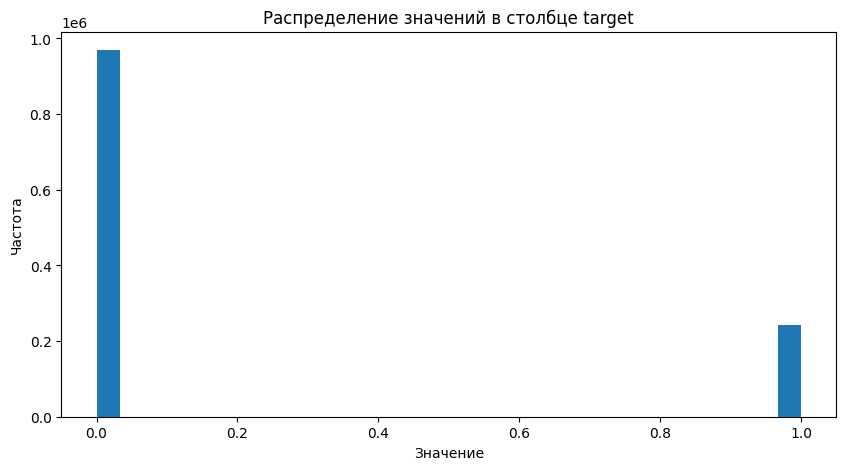

In [ ]:
# Смотрим на баланс классов и пропуски в таргет
scale_pos_weight = len(target[target==0]) / len(target[target==1])
print(f"Коэффициент дисбаланса классов: {scale_pos_weight:.2f}")
print(f"Пропущенных значений: {target.isna().sum()}")

# Гистограмма распределения
plt.figure(figsize=(10, 5))
target.hist(bins=30)
plt.title('Распределение значений в столбце target')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.grid(False)
plt.show()

In [ ]:
# Анализ тестовой выборки
empty_columns = df_test.columns[df_test.isnull().all()].tolist()
single_columns = [col for col in df_test.columns if df_test[col].nunique() == 1]
print("Пустые столбцы:", empty_columns)
print("Cтолбцы с одним значением:", single_columns)

Пустые столбцы: ['пени_за_дефолт', 'дата_следующей_выплаты']
Cтолбцы с одним значением: ['платежный_график', 'коэфф_невыплаченного_сумм_остатка', 'непогашенная_сумма_из_тела_займов', 'код_политики', 'особая_ситуация']


In [ ]:
# Удаляем бесполезные столбцы (пустые и с одним уникальным значением)
df = df.drop(columns=list(set(empty_columns) | set(single_columns)))
df_test = df_test.drop(columns=list(set(empty_columns) | set(single_columns)))

## 2. Ручная обработка категориальных фич

In [ ]:
def prepare_binary_features(train_df, test_df=None):
    """
    Преобразует все бинарные object-колонки в числовые (0 и 1).
    Сохраняет соответствие значений между train и test.
    Возвращает:
    Преобразованные train_df и test_df (если передан)
    """
    train_df = train_df.copy()
    if test_df is not None:
        test_df = test_df.copy()

    binary_cols = [
        col for col in train_df.select_dtypes(include=['object']).columns
        if train_df[col].nunique() == 2
    ]

    # Создаем и применяем кодировщики
    encoders = {}
    for col in binary_cols:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col])
        encoders[col] = le

        if test_df is not None and col in test_df:
            unseen = set(test_df[col].unique()) - set(le.classes_)
            if unseen:
                print(f"Внимание: в колонке '{col}' тестовой выборки найдены новые значения: {unseen}")
                most_frequent = train_df[col].mode()[0]
                test_df[col] = test_df[col].replace(list(unseen), most_frequent)
            test_df[col] = le.transform(test_df[col])

    return (train_df, test_df) if test_df is not None else train_df

df, df_test = prepare_binary_features(df, df_test)

In [ ]:
# Удаляем 'регион'
df.drop('регион', axis=1, inplace=True)
df_test.drop('регион', axis=1, inplace=True)


# Замена'профессия_заемщика' на частоту встречаемости
freq_ranking = df['профессия_заемщика'].value_counts().rank(ascending=False, method='dense').astype(int)
df['профессия_заемщика2'] = df['профессия_заемщика'].map(freq_ranking)
df.drop('профессия_заемщика', axis=1, inplace=True)

df_test['профессия_заемщика2'] = df_test['профессия_заемщика'].map(freq_ranking)
df_test.drop('профессия_заемщика', axis=1, inplace=True)
df['профессия_заемщика2'] = df['профессия_заемщика2'].fillna(0)
df_test['профессия_заемщика2'] = df_test['профессия_заемщика2'].fillna(0)

In [ ]:
#Ранжировка признака дата_первого_займа

# 1. Извлекаем год из даты
df['год'] = df['дата_первого_займа'].str.split('-').str[1].astype(int)
# 2. Создаем словарь соответствия года и его ранга
year_rank = {year: rank+1 for rank, year in enumerate(sorted(df['год'].unique()))}
# 3. Заменяем год на соответствующий ранг
df['год_первого_займа'] = df['год'].map(year_rank)
df.drop(['год'], axis=1, inplace=True)
df.drop(['дата_первого_займа'], axis=1, inplace=True)
df_test['год'] = df_test['дата_первого_займа'].str.split('-').str[1].astype(int)
year_rank = {year: rank+1 for rank, year in enumerate(sorted(df_test['год'].unique()))}
df_test['год_первого_займа'] = df_test['год'].map(year_rank)
df_test.drop(['год'], axis=1, inplace=True)
df_test.drop(['дата_первого_займа'], axis=1, inplace=True)

In [ ]:
# Заменяем признаки на числа по отношению порядка

def obj_replace(df):
  maindf=df.copy()
  maindf['рейтинг'] = maindf['рейтинг'].replace({
      'А': 0,
      'Б': 1,
      'В': 2,
      'Г': 3,
      'Д': 4,
      'Е': 5,
      'Ж': 6
  })

  rating_order = [
    'А1', 'А2', 'А3', 'А4', 'А5',
    'Б1', 'Б2', 'Б3', 'Б4', 'Б5',
    'В1', 'В2', 'В3', 'В4', 'В5',
    'Г1', 'Г2', 'Г3', 'Г4', 'Г5',
    'Д1', 'Д2', 'Д3', 'Д4', 'Д5',
    'Е1', 'Е2', 'Е3', 'Е4', 'Е5',
    'Ж1', 'Ж2', 'Ж3', 'Ж4', 'Ж5'
  ]

  rating_mapping = {rating: i+1 for i, rating in enumerate(rating_order)}

  maindf['допрейтинг'] = maindf['допрейтинг'].map(rating_mapping)

  maindf['стаж'] = maindf['стаж'].replace({
      '10+ лет': 11,
      '9 лет': 10,
      '8 лет': 9,
      '7 лет': 8,
      '6 лет': 7,
      '5 лет': 6,
      '4 года': 5,
      '3 года': 4,
      '2 года': 3,
      '1 год': 2,
      '< 1 года': 1
  })
  maindf['стаж'] = maindf['стаж'].fillna(0)

  maindf['владение_жильем'] = maindf['владение_жильем'].replace({
      'НЕТ': 0,
      'ДРУГОЕ': 1,
      'ЛЮБОЕ': 2,
      'ИПОТЕКА': 4,
      'АРЕНДА': 3,
      'СОБСТВЕННОСТЬ': 5
  })

  maindf['подтвержден_ли_доход'] = maindf['подтвержден_ли_доход'].replace({
      'Подтвержден источник': 2,
      'Подтвержден': 1,
      'Не подтвержден': 0
  })

  industry_encoded = pd.get_dummies(maindf['цель_займа'], prefix='goal')
  maindf = pd.concat([maindf, industry_encoded], axis=1)
  maindf.drop('цель_займа', axis=1, inplace=True)

  maindf['пос_стоп_фактор'] = maindf['пос_стоп_фактор'].replace({
      'Нет': 0,
      'Под вопросом': 1,
      'Да': 2
  })

  maindf['совокупный_статус_подтверждения_доходов_заемщиков'] = maindf['совокупный_статус_подтверждения_доходов_заемщиков'].replace({
      'Не подтвержден': 0,
      'Подтвержден': 1,
      'Подтвержден источник': 2
  })

  maindf['совокупный_статус_подтверждения_доходов_заемщиков'] = maindf['совокупный_статус_подтверждения_доходов_заемщиков'].fillna(0)

  return maindf

df = obj_replace(df)
df_test = obj_replace(df_test)

/tmp/ipython-input-3952167028.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  maindf['рейтинг'] = maindf['рейтинг'].replace({
/tmp/ipython-input-3952167028.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  maindf['стаж'] = maindf['стаж'].replace({
/tmp/ipython-input-3952167028.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future

## 3. Использованные методы

### Пропуски, корреляция между собой

In [ ]:
#Удаление признаков с одним уникальным значением, с процентом пропусков >miss,
#с корреляцией между собой >correletion.

def del_bad_feature(df, miss = 0.7, fl_cor = True, correletion = 0.95):
  #df=df2.copy()
  print("Удаляем                |  Кол-во")

  # Удаление признаков с одним уникальным значением
  to_drop_single = [col for col in df.columns if df[col].nunique() == 1]
  print("Признаки с 1 значением:  ", len(to_drop_single))

  # Удаление признаков с >70% пропусков
  missing_threshold = miss
  to_drop_missing = df.columns[df.isnull().mean() > missing_threshold]
  print("Признаки с пропусками:  ", len(to_drop_missing))

  to_drop = list(set(to_drop_missing) | set(to_drop_single))
  df = df.drop(columns = to_drop)

    # Удаление признаков с корреляцией >0.95
  if fl_cor:
    corr_threshold = correletion
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones_like(corr_matrix), k=1).astype(bool))
    to_drop_corr = [column for column in upper.columns if any(upper[column] > corr_threshold)]
    print("Признаки с корреляцией:  ", len(to_drop_corr))

    df = df.drop(columns=set(to_drop_corr))
    to_drop = list(set(to_drop) | set(to_drop_corr))

  #print(df2.shape, ' --> ', df.shape, '\n')
  return df, to_drop


#Заменяем все пропуски на медиану и переводим булеаны в числа
def median_bulean(clean_df, fl_replace = 'median'):
  for col in clean_df.columns:
      if clean_df[col].dtype == 'bool' or set(clean_df[col].unique()) == {True, False}:
          clean_df[col] = clean_df[col].astype(int)
  if fl_replace == 'median':
    clean_df = clean_df.fillna(clean_df.median())
  elif fl_replace == 'mean':
    clean_df = clean_df.fillna(clean_df.mean())
  elif fl_replace == 'zero':
    clean_df = clean_df.fillna(0)
  return clean_df

In [ ]:
df, del_feat = del_bad_feature(df, miss=0.7, fl_cor=False, correletion=0.95)
df = median_bulean(df, fl_replace = 'zero')

df_test = df_test.drop(columns=del_feat)
df_test = median_bulean(df_test, fl_replace = 'zero')

Удаляем                |  Кол-во
Признаки с 1 значением:   0
Признаки с пропусками:   6


### Cинтетические признаки

In [ ]:
#Функция для генерации доп фич
def new_feat_without_miss(df):

    # 1. Мои фичи

    epsilon = 1e-6
    df['log_сумма_просрочек'] = np.log1p(df['сумма_выплат_по_просрочкам'])
    bins = 30
    df['сумма_просрочек_бин'] = pd.cut(
        df['сумма_выплат_по_просрочкам'],
        bins=bins,
        labels=False
    ) + 1
    df['отношение_долга_выплат']=df['сумма_задолженности'] / (df['сумма_выплат_по_просрочкам'] + epsilon)
    df['отнош_долга_просрочек'] = df['кол-во_просрочек_за_два_года']/(df['сумма_задолженности'] + epsilon)
    df['отнош_просрочек']=df['сумма_выплат_по_просрочкам']/(df['кол-во_просрочек_за_два_года'] + epsilon)
    df['активность_по_счетам'] = df['кол-во_открытых_счетов']/(df['кол-во_открытых_счетов_за_полгода']+epsilon)
    df['отнош_взысканий_полгода'] = df['кол-во_взысканий_за_последний_год']/(df['общая_сумма_взысканий']+epsilon)
    df['долг_относ_зп'] = df['сумма_задолженности']/(df['годовой_доход']+1)


    # 2. Фичи из важных признаков по catboost

    df['отношение_платежа_к_доходу'] = df['аннуитет'] / (df['годовой_доход'] + epsilon)
    df['отношение_задолженности_к_лимиту'] = df['кредитный_баланс_без_ипотеки'] / (df['кредитный_лимит'] + epsilon)

    df['кредитная_нагрузка'] = (df['сумма_выплат_по_просрочкам'] + df['аннуитет']) / (df['годовой_доход'] + epsilon)
    df['коэфф_рискованности_ставки'] = df['процентная_ставка'] * df['отношение_платежа_к_доходу'] * np.log1p(df['кол-во_просрочек_за_два_года'] + 1)
    df['динамика_кредитного_поведения'] = (df['кол-во_открытых_счетов_за_2_года'] - df['кол-во_ипотек']) / (df['кол-во_заявок_за_полгода'] + 1)
    df['скорректированный_PDI'] = df['пдн'] * (1 + df['отношение_задолженности_к_лимиту']) / (df['средний_баланс_текущих_счетов'] + epsilon)
    df['рейтинговый_мультипликатор'] = (df['нижний_порог_рейтинга_заемщика'] * df['индекс_проживания']) / (df['рейтинг'].astype('category').cat.codes + 1)
    df['коэфф_фин_устойчивости'] = (df['стаж'] * df['годовой_доход']) / (df['сумма_выплат_по_просрочкам'] + df['аннуитет'] + epsilon)
    df['композитный_риск'] = (df['процентная_ставка'] * df['отношение_платежа_к_доходу'] *
                         np.log1p(df['кол-во_просрочек_за_два_года'] + 1)) / \
                         (df['средний_баланс_текущих_счетов'] + df['годовой_доход']/12 + 1e-6)


    # 3. Deep Seek

    df['нагрузка_по_кредитам'] = df['сумма_займа'] / (df['годовой_доход'] + epsilon)
    df['доля_просроченных_счетов'] = df['кол-во_счетов_с_просрочкой_4_мес'] / (df['кол-во_счетов'] + 1)
    df['стабильность_платежей'] = df['кол-во_счетов_без_нарушений'] / (df['кол-во_счетов'] + 1)
    df['тренд_использования_кредита'] = (df['кол-во_открытых_счетов_за_полгода'] - df['кол-во_открытых_счетов_за_2_года']/4) / (df['кол-во_открытых_счетов_за_2_года']/4 + 1)
    df['комбинированный_рейтинг'] = (df['рейтинг'].astype('category').cat.codes + df['допрейтинг'].astype('category').cat.codes) / 2
    df['нормализованный_пдн'] = df['пдн'] / (df['годовой_доход'] + epsilon)
    df['доступный_кредитный_потенциал'] = (df['кредитный_лимит'] - df['кредитный_баланс_без_ипотеки']) / (df['годовой_доход'] + epsilon)
    df['коэфф_использования_кредита'] = df['общая_сумма_на_счетах'] / (df['кредитный_лимит'] + 1)
    df['изменение_кредитного_поведения'] = (df['кол-во_заявок_за_полгода'] - df['кол-во_заявок_на_кредит_за_год']/2) / (df['кол-во_заявок_на_кредит_за_год']/2 + 1)
    df['динамика_просрочек'] = (df['кол-во_просрочек_за_два_года'] - df['кол-во_взысканий_за_последний_год']*2) / (df['кол-во_взысканий_за_последний_год']*2 + 1)
    df['флаг_критической_нагрузки'] = (df['отношение_платежа_к_доходу'] > 0.4).astype(int)
    df['флаг_активных_просрочек'] = (df['кол-во_текущих_просроченных_счетов'] > 0).astype(int)


    for col in df.select_dtypes(include=['float64']).columns: # Заменяем бесконечности
        df[col] = df[col].fillna(df[col].median())
        df[col] = df[col].replace(np.inf, np.nan)
        max_val = df[col].max()
        df[col] = df[col].fillna(max_val)
        df[col] = df[col].replace(-np.inf, np.nan)
        min_val = df[col].min()
        df[col] = df[col].fillna(min_val)

    return df
print(df.shape, ' --> ')
df = new_feat_without_miss(df)
df_test = new_feat_without_miss(df_test)
print(df.shape)

(1210779, 107)  --> 
(1210779, 136)


### Низкая корреляция с target

In [ ]:
def remove_low_correlation_features(df, target_col, threshold=0.01,
                                   correlation_method='pearson',
                                   keep_features=None):
    """
    Удаляет признаки с корреляцией с целевой переменной ниже threshold.

    keep_features : list, optional (default=None)
        Список признаков, которые нужно сохранить независимо от корреляции
    """

    df_copy = df.copy()
    df_copy['target_col'] = target_col

    correlations = df_copy.corr(method=correlation_method)['target_col'].abs()
    features_to_drop = correlations[correlations < threshold].index.tolist()
    if keep_features is not None:
        features_to_drop = [f for f in features_to_drop if f not in keep_features]

    df_filtered = df_copy.drop(columns=features_to_drop)
    print('Удалено:', len(features_to_drop))
    print(df.shape, '--->', df_filtered.shape)

    return df_filtered, features_to_drop

In [ ]:
# Для DataFrame с признаками (df_features) и отдельного DataFrame с целевой переменной (df_target)
df2, low_cor_feat = remove_low_correlation_features(df, target)
df2.drop('target_col', axis=1, inplace=True)
df_test2 = df_test.drop(columns=low_cor_feat)

Удалено: 47
(1210779, 136) ---> (1210779, 90)


In [ ]:
# Возвращаем признаки которые (как выяснилось в дальнейшем) являются важными!
df2['композитный_риск'] = df['композитный_риск']
df2['нагрузка_по_кредитам'] = df['нагрузка_по_кредитам']
df_test2['композитный_риск'] = df_test['композитный_риск']
df_test2['нагрузка_по_кредитам'] = df_test['нагрузка_по_кредитам']

### Низкая дисперсия

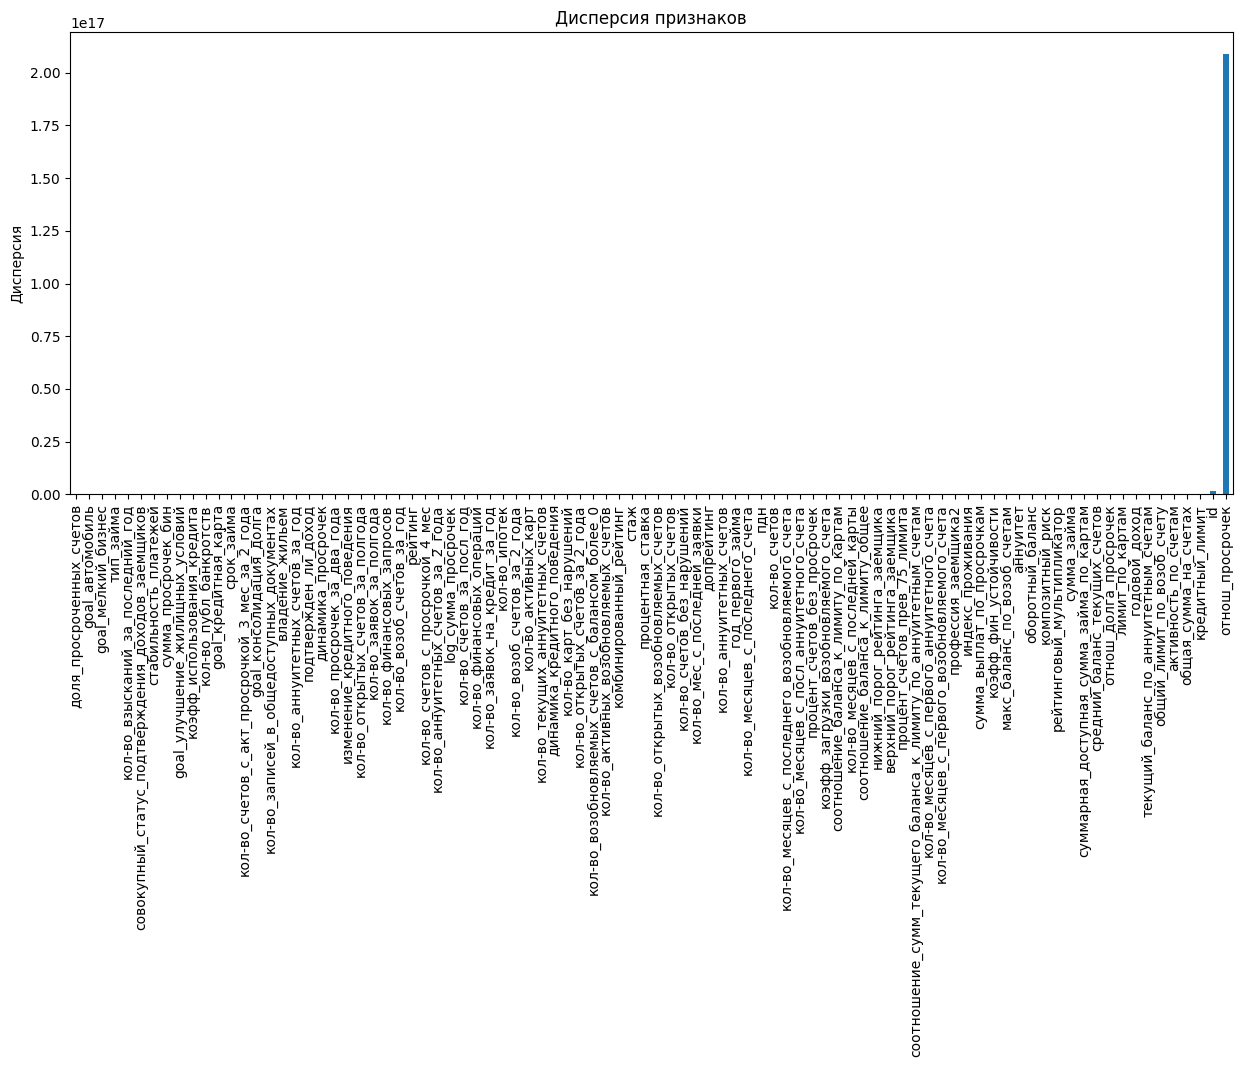

In [ ]:
# Вычисляем дисперсию
variances = df2.var()

# Визуализация
plt.figure(figsize=(15, 6))
variances.sort_values().iloc[:-1].plot(kind='bar')
plt.title('Дисперсия признаков')
plt.ylabel('Дисперсия')
plt.show()

In [ ]:
disp = 0.01
print("Удаляем:", len(variances.loc[variances< disp]))
# Удаление признаков с дисперсией < disp
selector = VarianceThreshold(threshold=disp)
selector.fit(df2)

Удаляем: 1


VarianceThreshold(threshold=0.01)

In [ ]:
dropped_features

{'доля_просроченных_счетов'}

In [ ]:
# Получаем маску и названия сохраненных признаков
selected_mask = selector.get_support()
selected_features = df2.columns[selected_mask]
dropped_features = set(df2.columns) - set(selected_features)

# Создаем новые DataFrame с сохраненной структурой
df2 = pd.DataFrame(
    selector.transform(df2),
    columns=selected_features,
    index=df2.index
)

df_test2 = pd.DataFrame(
    selector.transform(df_test2),
    columns=selected_features,
    index=df_test2.index
)

print(f'Кол-во признаков: {df2.shape[1]}')

Кол-во признаков: 90


## 4. Методы, которые не улучшили метрику

### Обработка выбросов

In [ ]:
def fit_outlier_transformer(train_df):
    """Рассчитывает параметры для обработки выбросов (на train данных)"""
    numeric_cols = train_df.select_dtypes(include=np.number).columns
    params = {}

    for col in numeric_cols:
        params[col] = {
            'lower': train_df[col].quantile(0.025),
            'upper': train_df[col].quantile(0.975),
            'median': train_df[col].median()
        }
    return params

def transform_outliers(df, params):
    """Применяет обработку выбросов с сохраненными параметрами"""
    df_clean = df.copy()
    for col, bounds in params.items():
        df_clean[col] = np.where(
            (df_clean[col] < bounds['lower']) | (df_clean[col] > bounds['upper']),
            bounds['median'],
            df_clean[col]
        )
    return df_clean


outlier_params = fit_outlier_transformer(df2)

df3 = transform_outliers(df2, outlier_params)
df_test3 = transform_outliers(df_test2, outlier_params)

### F-test

In [ ]:
df3, del_feat = del_bad_feature(df2, miss=0.7, fl_cor=True, correletion=0.95)
df3.shape

Удаляем                |  Кол-во
Признаки с 1 значением:   0
Признаки с пропусками:   0
Признаки с корреляцией:   9


(1210779, 81)

In [ ]:
df_cur = df3
# проверяем стат. значимость связи
selector = SelectKBest(score_func=f_regression, k=60)
selector.fit(df_cur, target)
# Получаем выбранные признаки
selected_mask = selector.get_support()
selected_features = df_cur.columns[selected_mask]
dropped_features = set(df_cur.columns) - set(selected_features)

In [ ]:
# F-статистики и p-values
f_scores = pd.Series(selector.scores_, index=df_cur.columns)
p_values = pd.Series(selector.pvalues_, index=df_cur.columns)

print("\nТоп-5 признаков по F-статистике:")
print(f_scores.sort_values(ascending=False).head(5))

print("\nПризнаки с наименьшими p-values:")
print(p_values.sort_values().head(5))


Топ-5 признаков по F-статистике:
процентная_ставка             86541.923719
log_сумма_просрочек           58189.961268
срок_займа                    38509.757424
рейтинговый_мультипликатор    27876.147239
сумма_выплат_по_просрочкам    24333.542185
dtype: float64

Признаки с наименьшими p-values:
id                   0.0
сумма_займа          0.0
срок_займа           0.0
процентная_ставка    0.0
владение_жильем      0.0
dtype: float64


In [ ]:
df3_list = selector.transform(df_cur)

# Для интерпретации преобразуем в DataFrame
df3 = pd.DataFrame(df3_list, columns=selected_features, index=df_cur.index)

### Новые признаки как комбинации важных

In [ ]:
def new_important_feat(df):
    """
      Изначально рандомно выбиралось 100 комбинаций по 3 признака.
    И все передавались в LightGBM. Было 3 запуска: для произведения признаков,
    среднего значения и (f1 * f2 / f3)

      В этой функции остались только признаки входившие в топ 30 важных.
    """
    epsilon = 1e-6

    #1. Произведение важных фич по 3 шт

    df['1динамика_кредитного_поведения_кол-во_открытых_счетов_за_2_года_срок_займа'] = df[['динамика_кредитного_поведения', 'кол-во_открытых_счетов_за_2_года', 'срок_займа']].prod(axis=1)
    df['1допрейтинг_рейтинг_кол-во_открытых_счетов_за_2_года'] = df[['допрейтинг', 'рейтинг', 'кол-во_открытых_счетов_за_2_года']].prod(axis=1)
    df['1кол-во_активных_возобновляемых_счетов_комбинированный_рейтинг_рейтинг'] = df[['кол-во_активных_возобновляемых_счетов', 'комбинированный_рейтинг', 'рейтинг']].prod(axis=1)
    df['1динамика_кредитного_поведения_комбинированный_рейтинг_пдн'] = df[['динамика_кредитного_поведения', 'комбинированный_рейтинг', 'пдн']].prod(axis=1)
    df['1нижний_порог_рейтинга_заемщика_рейтинг_срок_займа'] = df[['нижний_порог_рейтинга_заемщика', 'рейтинг', 'срок_займа']].prod(axis=1)
    df['1пдн_рейтинг_сумма_просрочек_бин'] = df[['пдн', 'рейтинг', 'сумма_просрочек_бин']].prod(axis=1)
    df['1log_сумма_просрочек_отнош_просрочек_рейтинговый_мультипликатор'] = df[['log_сумма_просрочек', 'отнош_просрочек', 'рейтинговый_мультипликатор']].prod(axis=1)
    df['1комбинированный_рейтинг_процентная_ставка_сумма_просрочек_бин'] = df[['комбинированный_рейтинг', 'процентная_ставка', 'сумма_просрочек_бин']].prod(axis=1)
    df['1верхний_порог_рейтинга_заемщика_рейтинговый_мультипликатор_сумма_выплат_по_просрочкам'] = df[['сумма_выплат_по_просрочкам', 'рейтинговый_мультипликатор', 'верхний_порог_рейтинга_заемщика']].prod(axis=1)
    df['1log_сумма_просрочек_верхний_порог_рейтинга_заемщика_комбинированный_рейтинг'] = df[['log_сумма_просрочек', 'верхний_порог_рейтинга_заемщика', 'комбинированный_рейтинг']].prod(axis=1)


    #2. Произведение двух делёное на третий признак
    df['2допрейтинг_комбинированный_рейтинг_нижний_порог_рейтинга_заемщика'] = df['допрейтинг'] * df['комбинированный_рейтинг'] / (epsilon + df['нижний_порог_рейтинга_заемщика'])
    df['2log_сумма_просрочек_рейтинг_сумма_просрочек_бин'] = df['log_сумма_просрочек'] * df['рейтинг'] / (epsilon + df['сумма_просрочек_бин'])
    df['2log_сумма_просрочек_нижний_порог_рейтинга_заемщика_процентная_ставка'] = df['log_сумма_просрочек'] * df['нижний_порог_рейтинга_заемщика'] / (epsilon + df['процентная_ставка'])
    df['2допрейтинг_пдн_сумма_просрочек_бин'] = df['допрейтинг'] * df['пдн'] / df['сумма_просрочек_бин']
    df['2рейтинг_срок_займа_сумма_просрочек_бин'] = df['рейтинг'] * df['срок_займа'] / df['сумма_просрочек_бин']
    df['2нижний_порог_рейтинга_заемщика_процентная_ставка_срок_займа'] = df['нижний_порог_рейтинга_заемщика'] * df['процентная_ставка'] / (epsilon + df['срок_займа'])
    df['2log_сумма_просрочек_верхний_порог_рейтинга_заемщика_отнош_просрочек'] = df['log_сумма_просрочек'] * df['верхний_порог_рейтинга_заемщика'] / (epsilon + df['отнош_просрочек'])
    df['2log_сумма_просрочек_допрейтинг_нижний_порог_рейтинга_заемщика'] = df['log_сумма_просрочек'] * df['допрейтинг'] / (epsilon + df['нижний_порог_рейтинга_заемщика'])
    df['2кол-во_открытых_счетов_за_2_года_пдн_сумма_просрочек_бин'] = df['кол-во_открытых_счетов_за_2_года'] * df['пдн'] / (epsilon + df['сумма_просрочек_бин'])
    df['2log_сумма_просрочек_верхний_порог_рейтинга_заемщика_кол-во_счетов_за_посл_год'] = df['log_сумма_просрочек'] * df['верхний_порог_рейтинга_заемщика'] / (epsilon + df['кол-во_счетов_за_посл_год'])
    df['2кол-во_активных_возобновляемых_счетов_комбинированный_рейтинг_нижний_порог_рейтинга_заемщика'] = df['кол-во_активных_возобновляемых_счетов'] * df['комбинированный_рейтинг'] / (epsilon + df['нижний_порог_рейтинга_заемщика'])
    df['2log_сумма_просрочек_верхний_порог_рейтинга_заемщика_сумма_выплат_по_просрочкам'] = df['log_сумма_просрочек'] * df['верхний_порог_рейтинга_заемщика'] / (epsilon + df['сумма_выплат_по_просрочкам'])
    df['2комбинированный_рейтинг_отнош_просрочек_рейтинговый_мультипликатор'] = df['комбинированный_рейтинг'] * df['отнош_просрочек'] / (epsilon + df['рейтинговый_мультипликатор'])
    df['2динамика_кредитного_поведения_рейтинг_рейтинговый_мультипликатор'] = df['динамика_кредитного_поведения'] * df['рейтинг'] / (epsilon +df['рейтинговый_мультипликатор'])
    df['2комбинированный_рейтинг_срок_займа_сумма_выплат_по_просрочкам'] = df['комбинированный_рейтинг'] * df['срок_займа'] / (epsilon +df['сумма_выплат_по_просрочкам'])
    df['2верхний_порог_рейтинга_заемщика_нижний_порог_рейтинга_заемщика_пдн'] = df['верхний_порог_рейтинга_заемщика'] * df['нижний_порог_рейтинга_заемщика'] / (epsilon +df['пдн'])
    df['2комбинированный_рейтинг_процентная_ставка_срок_займа'] = df['комбинированный_рейтинг'] * df['процентная_ставка'] / (epsilon +df['срок_займа'])

    #3. Среднее между тремя признаками
    df['3log_сумма_просрочек_допрейтинг_сумма_выплат_по_просрочкам'] = df[['log_сумма_просрочек', 'допрейтинг', 'сумма_выплат_по_просрочкам']].mean(axis=1)
    df['3log_сумма_просрочек_процентная_ставка_срок_займа'] = df[['log_сумма_просрочек', 'процентная_ставка', 'срок_займа']].mean(axis=1)
    df['3кол-во_открытых_счетов_за_2_года_отнош_просрочек_процентная_ставка'] = df[['кол-во_открытых_счетов_за_2_года', 'отнош_просрочек', 'процентная_ставка']].mean(axis=1)
    df['3допрейтинг_кол-во_возобновляемых_счетов_с_балансом_более_0_процентная_ставка'] = df[['допрейтинг', 'кол-во_возобновляемых_счетов_с_балансом_более_0', 'процентная_ставка']].mean(axis=1)
    df['3log_сумма_просрочек_допрейтинг_кол-во_счетов_за_посл_год'] = df[['log_сумма_просрочек', 'допрейтинг', 'кол-во_счетов_за_посл_год']].mean(axis=1)
    df['3динамика_кредитного_поведения_кол-во_возоб_счетов_за_2_года_комбинированный_рейтинг'] = df[['динамика_кредитного_поведения', 'кол-во_возоб_счетов_за_2_года', 'комбинированный_рейтинг']].mean(axis=1)
    df['3log_сумма_просрочек_кол-во_возоб_счетов_за_2_года_срок_займа'] = df[['log_сумма_просрочек', 'кол-во_возоб_счетов_за_2_года', 'срок_займа']].mean(axis=1)
    df['3срок_займа_сумма_выплат_по_просрочкам_сумма_просрочек_бин'] = df[['срок_займа', 'сумма_выплат_по_просрочкам', 'сумма_просрочек_бин']].mean(axis=1)
    df['3кол-во_активных_возобновляемых_счетов_пдн_сумма_выплат_по_просрочкам'] = df[['кол-во_активных_возобновляемых_счетов', 'пдн', 'сумма_выплат_по_просрочкам']].mean(axis=1)
    df['3динамика_кредитного_поведения_комбинированный_рейтинг_рейтинг'] = df[['динамика_кредитного_поведения', 'комбинированный_рейтинг', 'рейтинг']].mean(axis=1)
    df['3допрейтинг_кол-во_открытых_счетов_за_2_года_пдн'] = df[['допрейтинг', 'кол-во_открытых_счетов_за_2_года', 'пдн']].mean(axis=1)
    df['3допрейтинг_кол-во_активных_возобновляемых_счетов_срок_займа'] = df[['допрейтинг', 'кол-во_активных_возобновляемых_счетов', 'срок_займа']].mean(axis=1)
    df['3кол-во_открытых_счетов_за_2_года_комбинированный_рейтинг_процентная_ставка'] = df[['кол-во_открытых_счетов_за_2_года', 'комбинированный_рейтинг', 'процентная_ставка']].mean(axis=1)

    return df

In [ ]:
df3 = new_important_feat(df2)

#Удаляем сильно скоррелированные:
df3, del_feat3 = del_bad_feature(df3, fl_cor=True, correletion=0.95)
df3.shape

Удаляем                |  Кол-во
Признаки с 1 значением:   0
Признаки с пропусками:   0
Признаки с корреляцией:   19


(1210779, 111)

### Boruta

In [ ]:
# Параметры XGBoost для отбора
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 5,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'n_estimators': 100,
    'random_state': 42,
    'importance_type': 'gain',
    'tree_method': 'hist',
    'n_jobs': 1
}
xgb_model = XGBClassifier(**params)

# Настройки Boruta для более мягкого отбора (иначе остаётся мало признаков)
boruta = BorutaPy(
    estimator=xgb_model,
    n_estimators=200,
    max_iter=50,
    verbose=1,
    random_state=42,
    alpha=0.3,            # большое значение
    two_step=True,
    early_stopping=True,
    perc=90
)

# Работаем с подвыборкой данных (так как данных много)
sample_size = min(10000, len(df2))
if len(df2) > sample_size:
    idx = np.random.choice(len(df2), sample_size, replace=False)
    X_np = df2.iloc[idx].values if hasattr(df2, 'values') else df2[idx]
    y_np = target.iloc[idx].values if hasattr(target, 'values') else target[idx]
else:
    X_np = df2.values if hasattr(df2, 'values') else np.array(df2)
    y_np = target.values if hasattr(target, 'values') else np.array(target)

# Мониторинг памяти перед запуском
#!free -h  # Для Colab (показывает доступную память)

# Запуск Boruta с обработкой возможных ошибок
try:
    boruta.fit(X_np, y_np)
    print("\nРезультаты:")
    print("Подтвержденные признаки:", df2.columns[boruta.support_])
    print("Тентaтивные признаки:", df2.columns[boruta.support_weak_])
except Exception as e:
    print(f"Ошибка: {e}\nПопробуйте еще уменьшить параметры или размер данных")

# 6. Очистка памяти (особенно важно для Colab)
del X_np, y_np
#import gc
#gc.collect()

Iteration: 1 / 50
Iteration: 2 / 50
Early stopping: 2 out of 20
Iteration: 3 / 50
Early stopping: 3 out of 20
Iteration: 4 / 50
Iteration: 5 / 50
Iteration: 6 / 50
Early stopping: 2 out of 20
Iteration: 7 / 50
Early stopping: 3 out of 20
Iteration: 8 / 50
Iteration: 9 / 50
Iteration: 10 / 50
Early stopping: 2 out of 20
Iteration: 11 / 50
Early stopping: 3 out of 20
Iteration: 12 / 50
Iteration: 13 / 50
Early stopping: 2 out of 20
Iteration: 14 / 50
Early stopping: 3 out of 20
Iteration: 15 / 50
Iteration: 16 / 50
Early stopping: 2 out of 20
Iteration: 17 / 50
Early stopping: 3 out of 20
Iteration: 18 / 50
Early stopping: 4 out of 20
Iteration: 19 / 50
Early stopping: 5 out of 20
Iteration: 20 / 50
Early stopping: 6 out of 20
Iteration: 21 / 50
Iteration: 22 / 50
Early stopping: 2 out of 20
Iteration: 23 / 50
Iteration: 24 / 50
Iteration: 25 / 50
Early stopping: 2 out of 20
Iteration: 26 / 50
Early stopping: 3 out of 20
Iteration: 27 / 50
Iteration: 28 / 50
Early stopping: 2 out of 20
I

# Итоговая модель - LightGBM

In [ ]:
#  Разделение данных на обучающую и тестовую выборки
df_cur=df2

X_train, X_val, y_train, y_val = train_test_split(
    df_cur,
    target,
    test_size=0.1,
    random_state=42,
    stratify=target  # Стратификация для сохранения баланса классов
)
print(f'Кол-во id и признаков на валидации: {X_val.shape}')

Кол-во id и признаков на валидации: (121078, 130)


[LightGBM] [Info] Number of positive: 217525, number of negative: 872176
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.781339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10787
[LightGBM] [Info] Number of data points in the train set: 1089701, number of used features: 90
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199619 -> initscore=-1.388677
[LightGBM] [Info] Start training from score -1.388677
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

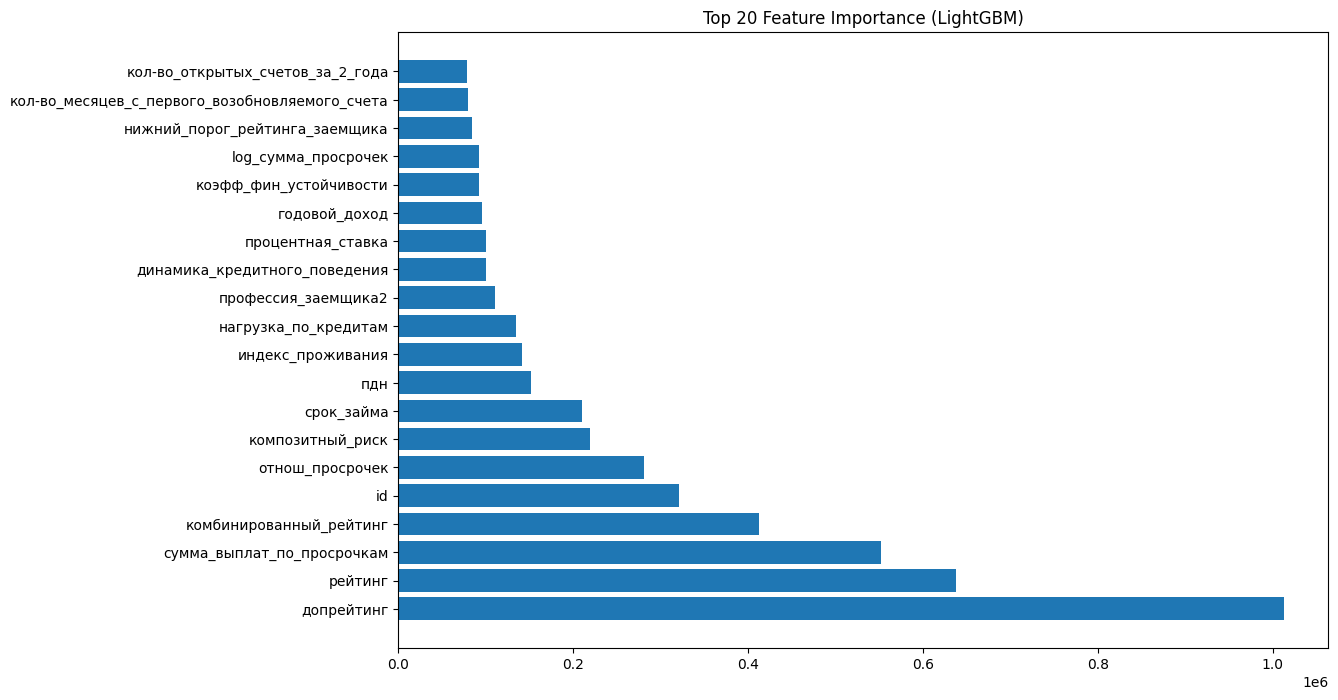


Топ-10 важных признаков:
                       feature    importance
6                   допрейтинг  1.013312e+06
5                      рейтинг  6.373583e+05
22  сумма_выплат_по_просрочкам  5.517734e+05
84     комбинированный_рейтинг  4.128936e+05
0                           id  3.205886e+05
78             отнош_просрочек  2.813524e+05
88            композитный_риск  2.196775e+05
2                   срок_займа  2.102713e+05
12                         пдн  1.518592e+05
11           индекс_проживания  1.410140e+05


In [ ]:
single_model_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 2200,
    'learning_rate': 0.03,
    'num_leaves': 63,
    'max_depth': 6,
    'min_child_samples': 20,
    'reg_lambda': 5,
    'feature_fraction': 0.7,  # Соответствует max_features=0.7 в bagging
    'bagging_fraction': 0.7,  # Соответствует max_samples=0.7
    'bagging_freq': 1,
    'min_split_gain': 0.01,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': 1
}


train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Обучение с ранней остановкой
lgb_model = lgb.train(
    single_model_params,
    train_data,
    valid_sets=[val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(100)
    ]
)

# Оценка модели
train_pred_lgb = lgb_model.predict(X_train)
train_auc = roc_auc_score(y_train, train_pred_lgb)
print(f"\nROC-AUC на обучении: {train_auc:.4f}")

val_pred_lgb = lgb_model.predict(X_val)
val_auc = roc_auc_score(y_val, val_pred_lgb)
print(f"ROC-AUC на валидации: {val_auc:.4f}")

# 6. Важность признаков
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

# Визуализация топ-20 признаков
plt.figure(figsize=(12, 8))
plt.barh(importance['feature'].head(20), importance['importance'].head(20))
plt.title('Top 20 Feature Importance (LightGBM)')
plt.show()

# 7. Дополнительная информация
print("\nТоп-10 важных признаков:")
print(importance.head(10))
#ROC-AUC на обучении: 0.8049
#ROC-AUC на валидации: 0.7673

In [ ]:
print(f"\nROC-AUC на обучении: {train_auc:.4f}")
print(f"ROC-AUC на валидации: {val_auc:.4f}")


ROC-AUC на обучении: 0.8049
ROC-AUC на валидации: 0.7673


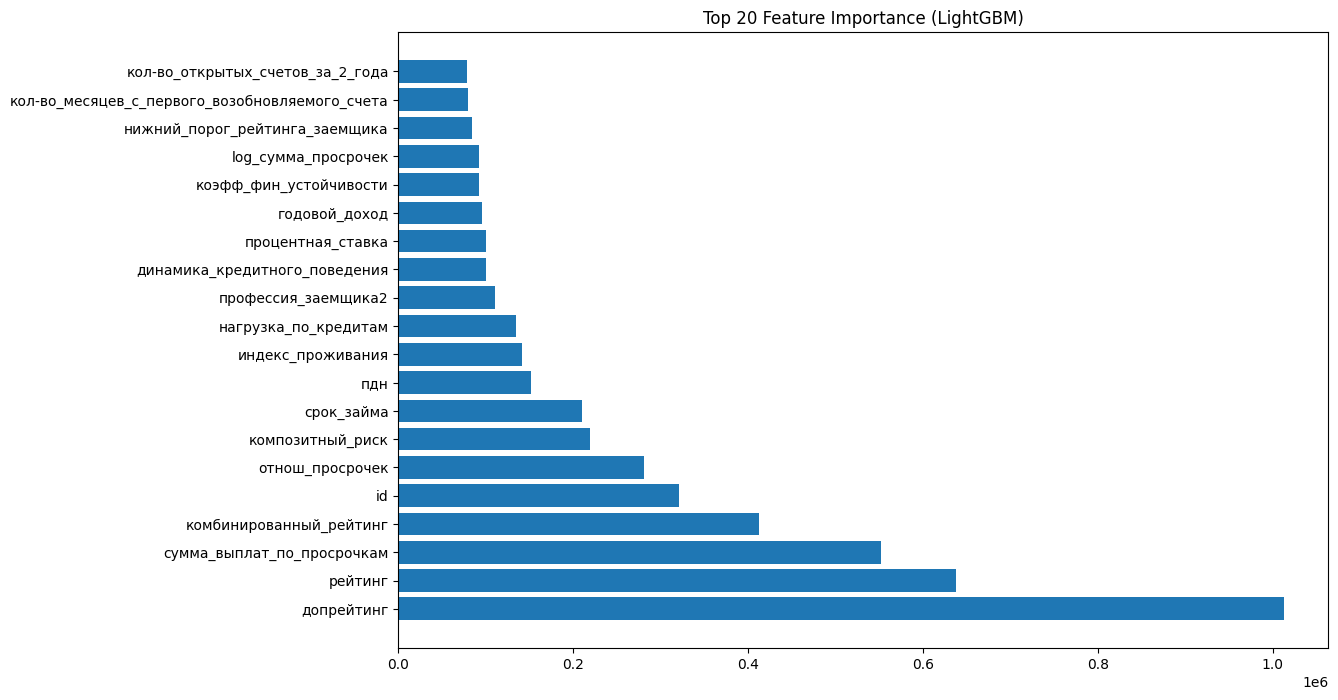


Топ-10 важных признаков:
                       feature    importance
6                   допрейтинг  1.013312e+06
5                      рейтинг  6.373583e+05
22  сумма_выплат_по_просрочкам  5.517734e+05
84     комбинированный_рейтинг  4.128936e+05
0                           id  3.205886e+05
78             отнош_просрочек  2.813524e+05
88            композитный_риск  2.196775e+05
2                   срок_займа  2.102713e+05
12                         пдн  1.518592e+05
11           индекс_проживания  1.410140e+05


In [ ]:
# Визуализация топ-20 признаков
plt.figure(figsize=(12, 8))
plt.barh(importance['feature'].head(20), importance['importance'].head(20))
plt.title('Top 20 Feature Importance (LightGBM)')
plt.show()

# 7. Дополнительная информация
print("\nТоп-10 важных признаков:")
print(importance.head(10))

# Формируем сабмит

In [ ]:
test_predict = lgb_model.predict(df_test2)

answer = pd.DataFrame()
answer['id'] = df_test['id']
answer['proba'] = test_predict
answer.to_csv('submission.csv', index=False)

# Другие использованные модели

In [ ]:
# модели
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ансамбли и мета-модели
from sklearn.ensemble import StackingClassifier, BaggingClassifier

# вспомогательные модули
from sklearn.base import BaseEstimator, ClassifierMixin
from itertools import product
import seaborn as sns

## Рандомный лес

In [ ]:
# Инициализация модели для классификации
clf_forest = RandomForestClassifier(
    max_depth=6,
    n_estimators=20,
    oob_score=True,  # OOB-оценка для классификации
    min_samples_split=5,
    min_samples_leaf=3,
    max_features=0.8,  # 80% признаков
    bootstrap=True,
    random_state=42,
    class_weight='balanced',  # Учет дисбаланса классов
    warm_start=True,
    verbose=3
)

# Обучение модели
clf_forest.fit(X_train, y_train)

# Предсказание вероятностей (класс 1)
train_proba = clf_forest.predict_proba(X_train)[:, 1]
test_proba = clf_forest.predict_proba(X_val)[:, 1]
oob_proba = clf_forest.oob_decision_function_[:, 1]  # OOB-вероятности

# Расчет ROC AUC
train_roc_auc = roc_auc_score(y_train, train_proba)
test_roc_auc = roc_auc_score(y_val, test_proba)
oob_roc_auc = roc_auc_score(y_train, oob_proba)

# Вывод метрик
print(
    f'Train ROC AUC: {train_roc_auc:.4f}\n'
    f'Test ROC AUC: {test_roc_auc:.4f}\n'
    f'OOB ROC AUC: {oob_roc_auc:.4f}\n'
)

# Дополнительные метрики классификации
print("Classification Report (Test Set):")
print(classification_report(y_val, clf_forest.predict(X_val)))

# Важность признаков
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': clf_forest.feature_importances_
}).sort_values('importance', ascending=False)

print("\nВажность признаков:")
print(importances.head(10))

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


building tree 1 of 20
building tree 2 of 20
building tree 3 of 20
building tree 4 of 20
building tree 5 of 20
building tree 6 of 20
building tree 7 of 20
building tree 8 of 20
building tree 9 of 20
building tree 10 of 20
building tree 11 of 20
building tree 12 of 20
building tree 13 of 20
building tree 14 of 20
building tree 15 of 20
building tree 16 of 20
building tree 17 of 20
building tree 18 of 20
building tree 19 of 20
building tree 20 of 20


[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed: 10.8min finished
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.2s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.3s finished


Train ROC AUC: 0.7309
Test ROC AUC: 0.7329
OOB ROC AUC: 0.7291

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.89      0.69      0.77    193817
           1       0.34      0.65      0.45     48339

    accuracy                           0.68    242156
   macro avg       0.61      0.67      0.61    242156
weighted avg       0.78      0.68      0.71    242156


Важность признаков:
                             feature  importance
2                  процентная_ставка    0.590527
25        сумма_выплат_по_просрочкам    0.245501
1                         срок_займа    0.075005
50     средний_баланс_текущих_счетов    0.022078
98        отношение_платежа_к_доходу    0.016023
42     кол-во_возоб_счетов_за_2_года    0.011846
11                               пдн    0.008582
99  отношение_задолженности_к_лимиту    0.006976
16    нижний_порог_рейтинга_заемщика    0.004225
3                               стаж    0.002954


[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.3s finished


## Catboost

In [ ]:
#Лучшие параметры после перебора
model_params = {
    'iterations': 1000,
    'learning_rate': 0.1,
    'depth': 8,
    'l2_leaf_reg': 3,
    'min_data_in_leaf': 5,
    'grow_policy': 'Depthwise',
    'border_count': 128,

    'random_seed': 42,
    'eval_metric': 'AUC',
    'early_stopping_rounds': 100,
    'verbose': 100,
    'auto_class_weights': 'Balanced',
    'task_type': 'CPU',
    'od_type': 'Iter'
}


# Инициализация и обучение модели
cat_model = CatBoostClassifier(**model_params)
cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
    plot=True
)

# Получение предсказаний (вероятности для класса 1)
train_proba = cat_model.predict_proba(X_train)[:, 1]
test_proba = cat_model.predict_proba(X_val)[:, 1]

# Вычисление метрик
train_auc = roc_auc_score(y_train, train_proba)
test_auc = roc_auc_score(y_val, test_proba)

print(f'\n=== Результаты ===')
print(f'ROC AUC на обучении: {train_auc:.4f}')
print(f'ROC AUC на тесте: {test_auc:.4f}')

# Важность признаков
feature_importance = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': cat_model.get_feature_importance()
}).sort_values('Важность', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

# Отчет классификации
print("\nОтчет классификации:")
print(classification_report(y_val, cat_model.predict(X_val)))

#=== Лучшие результаты ===
#ROC AUC на обучении: 0.8117
#ROC AUC на тесте: 0.7585

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.7265463	best: 0.7265463 (0)	total: 1.61s	remaining: 26m 50s
100:	test: 0.7541340	best: 0.7541340 (100)	total: 3m 40s	remaining: 32m 41s
200:	test: 0.7579747	best: 0.7579987 (199)	total: 7m 52s	remaining: 31m 18s
300:	test: 0.7583351	best: 0.7583723 (293)	total: 11m 4s	remaining: 25m 42s
400:	test: 0.7581003	best: 0.7584774 (364)	total: 13m 31s	remaining: 20m 12s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.758477412
bestIteration = 364

Shrink model to first 365 iterations.

=== Результаты ===
ROC AUC на обучении: 0.8117
ROC AUC на тесте: 0.7585

Топ-10 важных признаков:
                       Признак   Важность
4                      рейтинг  25.710526
19  сумма_выплат_по_просрочкам   7.053479
2            процентная_ставка   6.402593
70         log_сумма_просрочек   5.134750
72             отнош_просрочек   3.553231
1                   срок_займа   2.991048
10                         пдн   2.497190
76      коэфф_фин_устойчивости   1.927465
7        

### Random Search (30комбинаций)

Аналогичный код был использован для XGBoost и LightGBM

In [ ]:
"""
# Параметры для перебора
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1, 0.3],
    'l2_leaf_reg': [1, 3, 5],
    'grow_policy': ['SymmetricTree', 'Depthwise'],
    'min_data_in_leaf': [1, 5, 10],
    'border_count': [32, 64, 128]
}

# Базовые параметры
base_params = {
    'iterations': 300,  # Уменьшено для быстрого перебора
    'random_seed': 42,
    'eval_metric': 'AUC',
    'early_stopping_rounds': 30,
    'verbose': False,
    'auto_class_weights': 'Balanced',
    'task_type': 'CPU',
    'od_type': 'Iter'  # Обнаружение переобучения
    #'scale_pos_weight': 4  # Учет дисбаланса 1:4
}

# Функция для перебора параметров
def grid_search_catboost(X_train, y_train, X_test, y_test, param_grid, base_params, n_combinations=50):
    best_model = None
    best_params = {}
    best_test_auc = 0
    best_train_auc = 0
    results = []

    # Генерируем случайные комбинации параметров для экономии времени
    keys, values = zip(*param_grid.items())
    random_combinations = [dict(zip(keys, v)) for v in product(*values)]
    np.random.shuffle(random_combinations)
    combinations_to_try = random_combinations[:min(n_combinations, len(random_combinations))]

    print(f"Будет проверено {len(combinations_to_try)} комбинаций параметров...")

    for i, params in enumerate(combinations_to_try, 1):
        current_params = {**base_params, **params}

        # Выводим информацию о текущих параметрах
        print(f"\n=== Итерация {i}/{len(combinations_to_try)} ===")
        print("Текущие параметры:")
        for param, value in params.items():
            print(f"- {param}: {value}")
        print("="*30)

        model = CatBoostClassifier(**current_params)
        model.fit(
            X_train, y_train,
            eval_set=(X_test, y_test),
            use_best_model=True,
            verbose=False
        )

        train_proba = model.predict_proba(X_train)[:, 1]
        test_proba = model.predict_proba(X_test)[:, 1]

        train_auc = roc_auc_score(y_train, train_proba)
        test_auc = roc_auc_score(y_test, test_proba)

        results.append({
            'params': current_params,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'model': model
        })

        if test_auc > best_test_auc:
            best_test_auc = test_auc
            best_train_auc = train_auc
            best_params = current_params
            best_model = model

        print(f"Результат | Test AUC: {test_auc:.4f} | Best AUC: {best_test_auc:.4f}")
        print("-"*50)

    # Сортируем все результаты по test_auc
    sorted_results = sorted(results, key=lambda x: x['test_auc'], reverse=True)

    return best_model, best_params, best_train_auc, best_test_auc, sorted_results

# Запуск поиска
best_model, best_params, best_train_auc, best_test_auc, all_results = grid_search_catboost(
    X_train, y_train, X_test, y_test, param_grid, base_params, n_combinations=30
)

# Вывод результатов
print("\n=== Лучшая модель ===")
print(f"Лучшие параметры: {best_params}")
print(f"ROC AUC на обучении: {best_train_auc:.4f}")
print(f"ROC AUC на валидации: {best_test_auc:.4f}")

# Дополнительная информация о лучшей модели
print("\n=== Детали лучшей модели ===")
feature_importance = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': best_model.get_feature_importance()
}).sort_values('Важность', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

print("\nОтчет классификации:")
print(classification_report(y_test, best_model.predict(X_test)))

# Можно сохранить лучшую модель
# best_model.save_model('best_catboost_model.cbm')

# Вывод топ-5 комбинаций параметров
print("\n=== Топ-5 комбинаций параметров ===")
for i, res in enumerate(all_results[:5], 1):
    print(f"\n#{i} | Test AUC: {res['test_auc']:.4f}")
    print(f"Параметры: {res['params']}")
    """

Будет проверено 30 комбинаций параметров...

=== Итерация 1/30 ===
Текущие параметры:
- depth: 6
- learning_rate: 0.3
- l2_leaf_reg: 1
- grow_policy: SymmetricTree
- min_data_in_leaf: 1
- border_count: 128
Результат | Test AUC: 0.7587 | Best AUC: 0.7587
--------------------------------------------------

=== Итерация 2/30 ===
Текущие параметры:
- depth: 4
- learning_rate: 0.1
- l2_leaf_reg: 1
- grow_policy: Depthwise
- min_data_in_leaf: 10
- border_count: 128
Результат | Test AUC: 0.7558 | Best AUC: 0.7587
--------------------------------------------------

=== Итерация 3/30 ===
Текущие параметры:
- depth: 4
- learning_rate: 0.1
- l2_leaf_reg: 3
- grow_policy: Depthwise
- min_data_in_leaf: 1
- border_count: 128
Результат | Test AUC: 0.7563 | Best AUC: 0.7587
--------------------------------------------------

=== Итерация 4/30 ===
Текущие параметры:
- depth: 4
- learning_rate: 0.3
- l2_leaf_reg: 5
- grow_policy: Depthwise
- min_data_in_leaf: 1
- border_count: 128
Результат | Test AUC: 

## XGBoost

In [ ]:
# Лучшие параметры после перебора 30 комбинаций
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.09,
    'max_depth': 7,
    'min_child_weight': 10,
    'reg_lambda': 3,
    'grow_policy': 'depthwise',
    'subsample': 0.8,               # случайный отбор строк
    'colsample_bytree': 1.0,        # случайный отбор колонок
    'gamma': 0.0,
    'scale_pos_weight': scale_pos_weight,  # учет дисбаланса
    'n_estimators': 700,
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 50
}


# Обучение с ранней остановкой
xgb_model = XGBClassifier(**params)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# Оценка на валидации
val_pred_xgb = xgb_model.predict_proba(X_val)
val_auc = roc_auc_score(y_val, val_pred_xgb[:, 1])
train_pred_xgb = xgb_model.predict_proba(X_train)
train_auc = roc_auc_score(y_train, train_pred_xgb[:, 1])

print(f"\nROC-AUC на тесте: {train_auc:.4f}")
print(f"\nROC-AUC на валидации: {val_auc:.4f}")

#Лучшая метрика
#ROC-AUC на тесте: 0.7964
#ROC-AUC на валидации: 0.7601

Коэффициент дисбаланса: 4.01
[0]	validation_0-auc:0.73042
[100]	validation_0-auc:0.75548
[200]	validation_0-auc:0.75862
[300]	validation_0-auc:0.75983
[380]	validation_0-auc:0.75985

ROC-AUC на тесте: 0.7956

ROC-AUC на валидации: 0.7599


"\n# 9. Важность признаков\nimportance = pd.DataFrame({\n    'feature': X_train.columns,\n    'importance': xgb_model.feature_importances_\n}).sort_values('importance', ascending=False)\n\nplt.figure(figsize=(12, 8))\nplt.barh(importance['feature'].head(20), importance['importance'].head(20))\nplt.title('Top 20 Feature Importance')\nplt.show()\n\n# 10. Сохранение модели\n#xgb_model.save_model('best_xgboost_model.json')\n"

### XGBoost гиперпараметры

In [ ]:
# Параметры для перебора
param_grid = {
    'max_depth': [7, 8, 9],
    'learning_rate': [0.09, 0.1, 0.3],
    'reg_lambda': [1, 3, 5],  # Аналог l2_leaf_reg в CatBoost
    'grow_policy': ['depthwise', 'lossguide'],  # В XGBoost другие варианты
    'min_child_weight': [5, 7, 10],  # Аналог min_data_in_leaf
    'colsample_bytree': [1.0],  # Аналог feature_calibration
    'gamma': [0, 0.1, 0.3]  # Минимальное снижение loss для разделения
}

# Базовые параметры
base_params = {
    'n_estimators': 300,  # Аналог iterations
    'random_state': 42,
    'eval_metric': 'auc',
    'early_stopping_rounds': 30,
    'verbosity': 0,
    'scale_pos_weight': 4,  # Учет дисбаланса 1:4
    'objective': 'binary:logistic',
    'subsample': 0.8,
    'tree_method': 'hist',  # Для скорости
    'n_jobs': -1
}

# Функция для перебора параметров
def grid_search_xgboost(X_train, y_train, X_val, y_val, param_grid, base_params, n_combinations=50):
    best_model = None
    best_params = {}
    best_val_auc = 0
    best_train_auc = 0
    results = []

    # Генерируем случайные комбинации параметров
    keys, values = zip(*param_grid.items())
    random_combinations = [dict(zip(keys, v)) for v in product(*values)]
    np.random.shuffle(random_combinations)
    combinations_to_try = random_combinations[:min(n_combinations, len(random_combinations))]

    print(f"Будет проверено {len(combinations_to_try)} комбинаций параметров...")

    for i, params in enumerate(combinations_to_try, 1):
        current_params = {**base_params, **params}

        # Выводим информацию о текущих параметрах
        print(f"\n=== Итерация {i}/{len(combinations_to_try)} ===")
        print("Текущие параметры:")
        for param, value in params.items():
            print(f"- {param}: {value}")
        print("="*30)

        model = XGBClassifier(**current_params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        train_proba = model.predict_proba(X_train)[:, 1]
        val_proba = model.predict_proba(X_val)[:, 1]

        train_auc = roc_auc_score(y_train, train_proba)
        val_auc = roc_auc_score(y_val, val_proba)

        results.append({
            'params': current_params,
            'train_auc': train_auc,
            'val_auc': val_auc,
            'model': model
        })

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_train_auc = train_auc
            best_params = current_params
            best_model = model

        print(f"Результат | Val AUC: {val_auc:.4f} | Best AUC: {best_val_auc:.4f}")
        print("-"*50)

    # Сортируем все результаты по val_auc
    sorted_results = sorted(results, key=lambda x: x['val_auc'], reverse=True)

    return best_model, best_params, best_train_auc, best_val_auc, sorted_results

# Пример использования:
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Запуск поиска
best_model, best_params, best_train_auc, best_val_auc, all_results = grid_search_xgboost(
    X_train, y_train, X_val, y_val, param_grid, base_params, n_combinations=30
)

# Вывод результатов
print("\n=== Лучшая модель ===")
print(f"Лучшие параметры: {best_params}")
print(f"ROC AUC на обучении: {best_train_auc:.4f}")
print(f"ROC AUC на валидации: {best_val_auc:.4f}")

# Дополнительная информация о лучшей модели
print("\n=== Детали лучшей модели ===")
feature_importance = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': best_model.feature_importances_
}).sort_values('Важность', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

print("\nОтчет классификации:")
print(classification_report(y_val, best_model.predict(X_val)))

# Вывод топ-5 комбинаций параметров
print("\n=== Топ-5 комбинаций параметров ===")
for i, res in enumerate(all_results[:5], 1):
    print(f"\n#{i} | Val AUC: {res['val_auc']:.4f}")
    print(f"Параметры: {res['params']}")

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Признак'].head(20), feature_importance['Важность'].head(20))
plt.title('Top 20 Feature Importance')
plt.show()

# Сохранение модели
# best_model.save_model('best_xgboost_model.json')

Будет проверено 30 комбинаций параметров...

=== Итерация 1/30 ===
Текущие параметры:
- max_depth: 9
- learning_rate: 0.3
- reg_lambda: 3
- grow_policy: lossguide
- min_child_weight: 10
- colsample_bytree: 1.0
- gamma: 0
Результат | Val AUC: 0.7524 | Best AUC: 0.7524
--------------------------------------------------

=== Итерация 2/30 ===
Текущие параметры:
- max_depth: 7
- learning_rate: 0.3
- reg_lambda: 3
- grow_policy: depthwise
- min_child_weight: 5
- colsample_bytree: 1.0
- gamma: 0.3
Результат | Val AUC: 0.7561 | Best AUC: 0.7561
--------------------------------------------------

=== Итерация 3/30 ===
Текущие параметры:
- max_depth: 7
- learning_rate: 0.09
- reg_lambda: 3
- grow_policy: depthwise
- min_child_weight: 10
- colsample_bytree: 1.0
- gamma: 0
Результат | Val AUC: 0.7609 | Best AUC: 0.7609
--------------------------------------------------

=== Итерация 4/30 ===
Текущие параметры:
- max_depth: 9
- learning_rate: 0.1
- reg_lambda: 1
- grow_policy: depthwise
- min_chil

KeyboardInterrupt: 

### Распределения ошибок и важных фич

Вывод: некоторая корреляция между ошибками и распределениями данных имеется, например в выбросах,и возможная работа над этим могла бы улучшить метрику

In [ ]:
y_pred_prob = val_pred_xgb[:, 1]  # Вероятности класса 1
y_pred_class = (y_pred_prob > 0.5).astype(int)  # Преобразование в 0/1

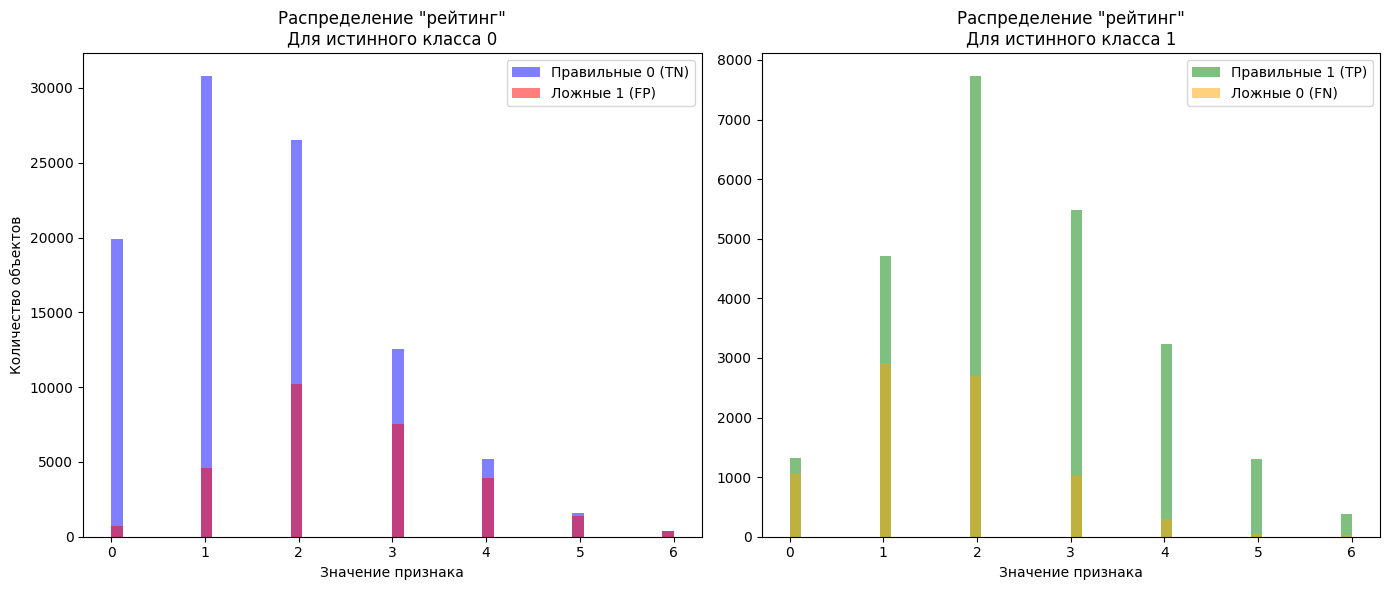

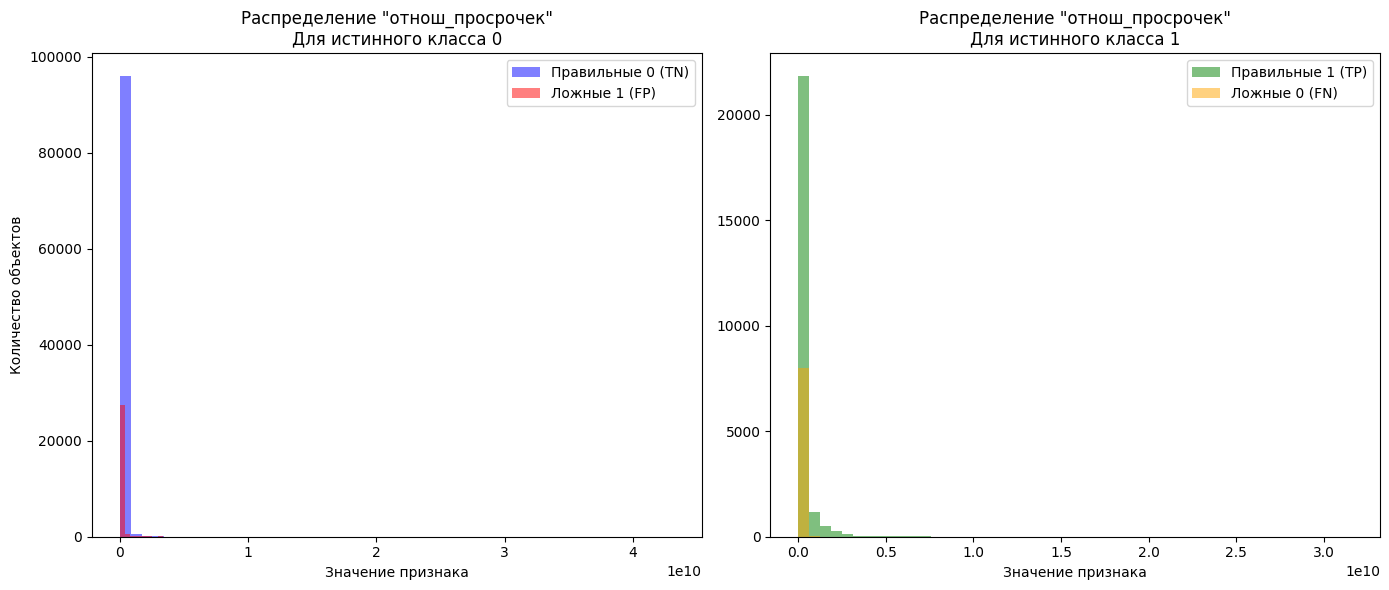

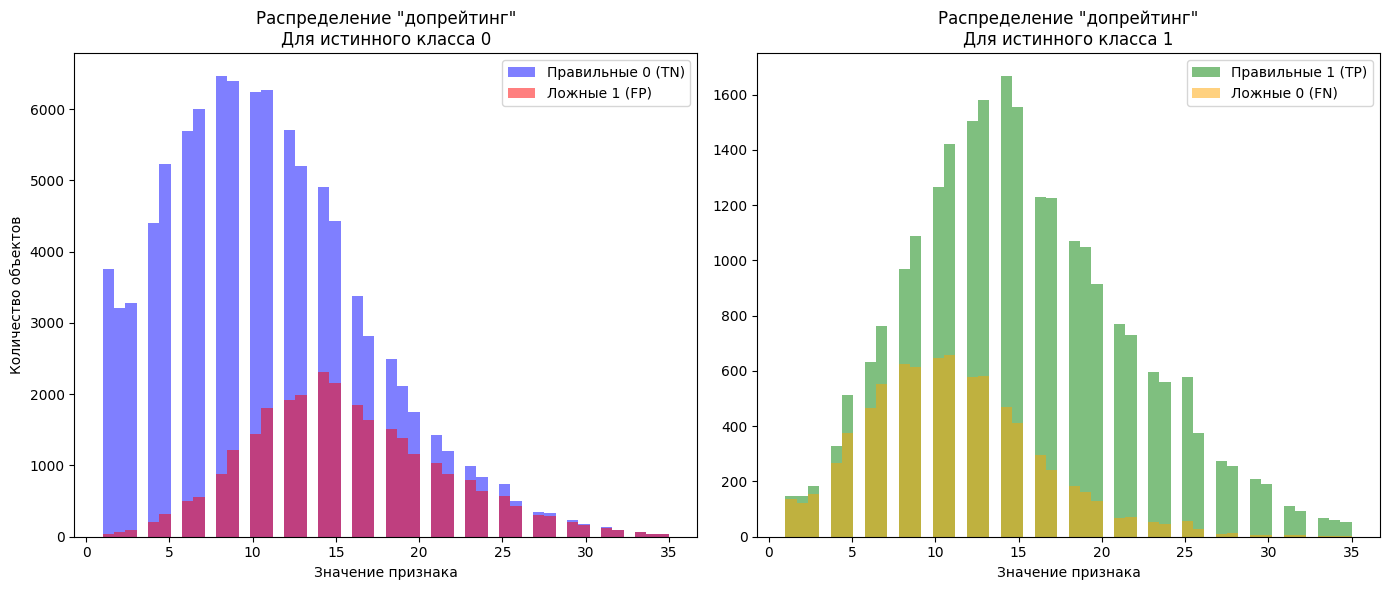

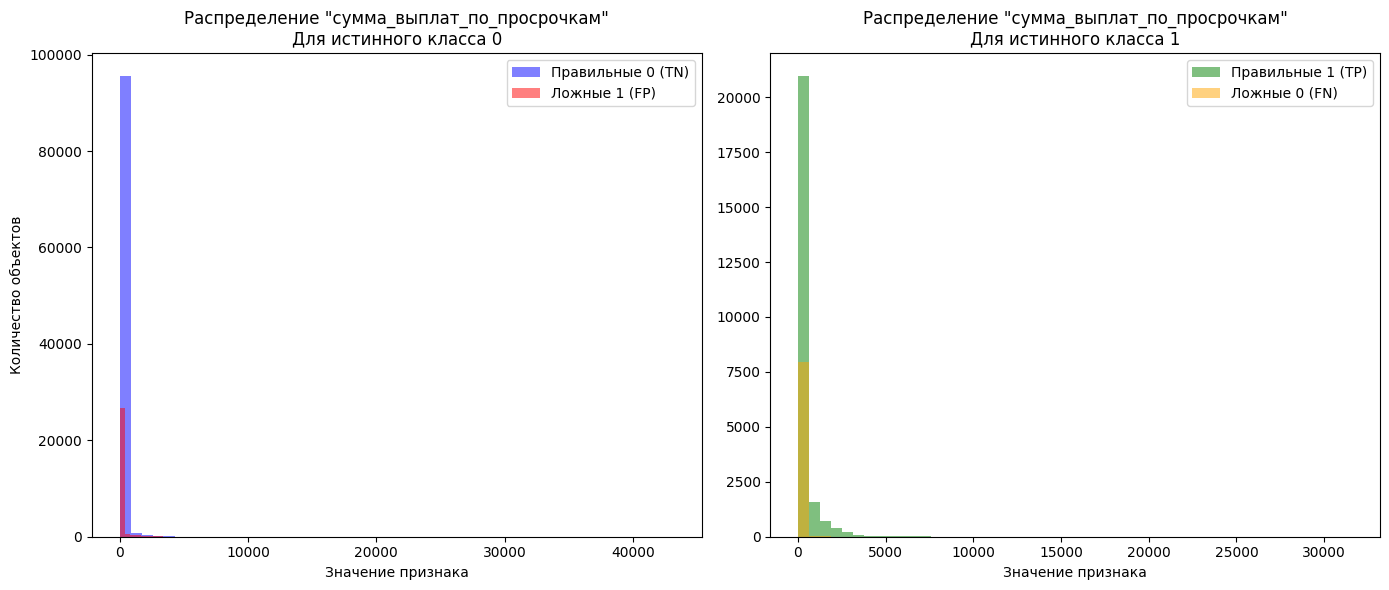

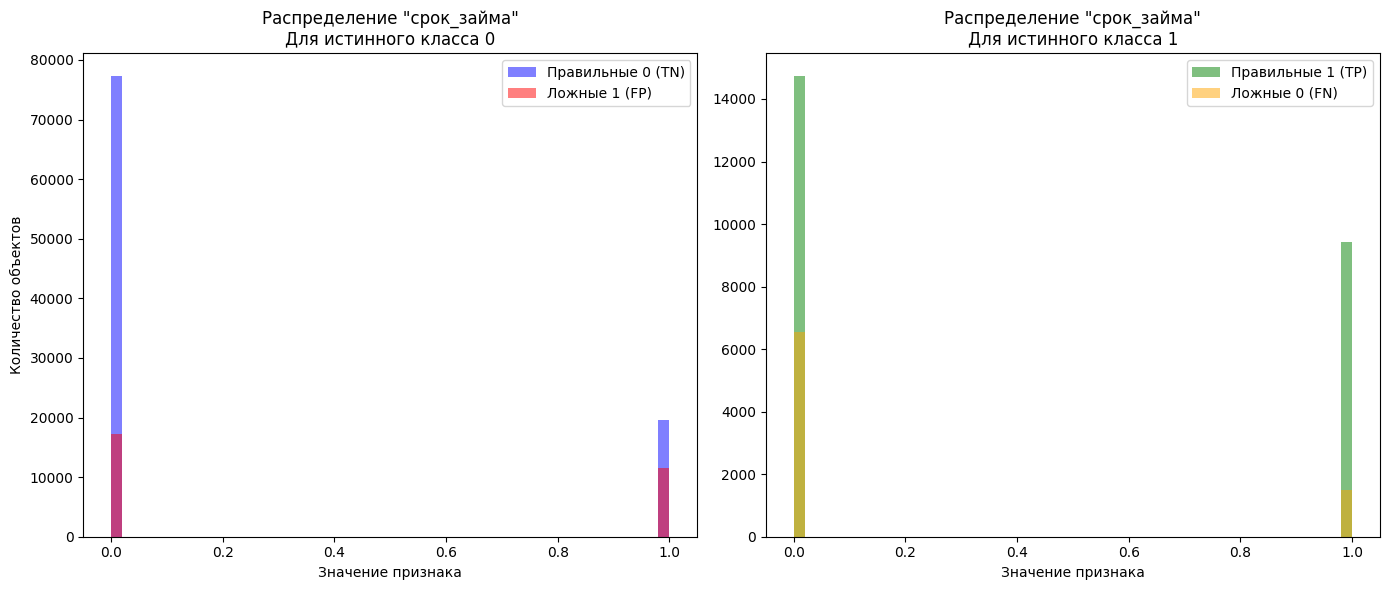


Анализ ложных положительных срабатываний (FP):
                                    mean   50%           std
рейтинг                     2.521542e+00   2.0  1.196803e+00
отнош_просрочек             7.758094e+07   0.0  4.755634e+08
допрейтинг                  1.563328e+01  15.0  5.833585e+00
сумма_выплат_по_просрочкам  1.153332e+02   0.0  5.953052e+02
срок_займа                  4.025286e-01   0.0  4.904159e-01


In [ ]:
# 1. Получаем важность признаков
if hasattr(xgb_model, 'feature_importances_'):
    feature_importance = xgb_model.feature_importances_
else:
    # Для StackingClassifier берем важность из первой модели
    feature_importance = xgb_model.estimators_[0].feature_importances_

top_features_idx = np.argsort(feature_importance)[-5:][::-1]  # Топ-5 важных
top_features_names = X_val.columns[top_features_idx]

# 2. Вычисляем типы ошибок
tn, fp, fn, tp = confusion_matrix(y_val, y_pred_class).ravel()

# 3. Создаем маски для разных типов предсказаний
mask_true_0 = (y_val == 0)
mask_false_1 = (y_val == 0) & (y_pred_class == 1)  # Ложные классы 1 (FP)
mask_true_1 = (y_val == 1)
mask_false_0 = (y_val == 1) & (y_pred_class == 0)  # Ложные классы 0 (FN)

# 4. Строим гистограммы для каждого признака
for feature in top_features_names:
    plt.figure(figsize=(14, 6))

    # График для класса 0
    plt.subplot(1, 2, 1)
    plt.hist(X_val.loc[mask_true_0, feature],
             bins=50, alpha=0.5, color='blue', label='Правильные 0 (TN)')
    plt.hist(X_val.loc[mask_false_1, feature],
             bins=50, alpha=0.5, color='red', label='Ложные 1 (FP)')
    plt.title(f'Распределение "{feature}"\nДля истинного класса 0')
    plt.xlabel('Значение признака')
    plt.ylabel('Количество объектов')
    plt.legend()

    # График для класса 1
    plt.subplot(1, 2, 2)
    plt.hist(X_val.loc[mask_true_1, feature],
             bins=50, alpha=0.5, color='green', label='Правильные 1 (TP)')
    plt.hist(X_val.loc[mask_false_0, feature],
             bins=50, alpha=0.5, color='orange', label='Ложные 0 (FN)')
    plt.title(f'Распределение "{feature}"\nДля истинного класса 1')
    plt.xlabel('Значение признака')
    plt.legend()

    plt.tight_layout()
    plt.show()

# 5. Дополнительно: вывод статистик по ошибкам FP
print("\nАнализ ложных положительных срабатываний (FP):")
fp_data = X_val.loc[mask_false_1, top_features_names]
print(fp_data.describe().loc[['mean', '50%', 'std']].T)

## LightGBM гиперпараметры

Будет проверено 30 комбинаций параметров...

=== Итерация 1/30 ===
Текущие параметры:
- num_leaves: 63
- learning_rate: 0.09
- reg_lambda: 5
- min_child_samples: 5
- feature_fraction: 0.9
- min_split_gain: 0
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[295]	valid_0's auc: 0.761985
Результат | Val AUC: 0.7620 | Best AUC: 0.7620
--------------------------------------------------

=== Итерация 2/30 ===
Текущие параметры:
- num_leaves: 50
- learning_rate: 0.08
- reg_lambda: 3
- min_child_samples: 5
- feature_fraction: 0.9
- min_split_gain: 0.15
Training until validation scores don't improve for 30 rounds
Результат | Val AUC: 0.7618 | Best AUC: 0.7620
--------------------------------------------------

=== Итерация 3/30 ===
Текущие параметры:
- num_leaves: 63
- learning_rate: 0.1
- reg_lambda: 1
- min_child_samples: 10
- feature_fraction: 0.8
- min_split_gain: 0.15
Training until validation scores don't improve for 30 rounds
D

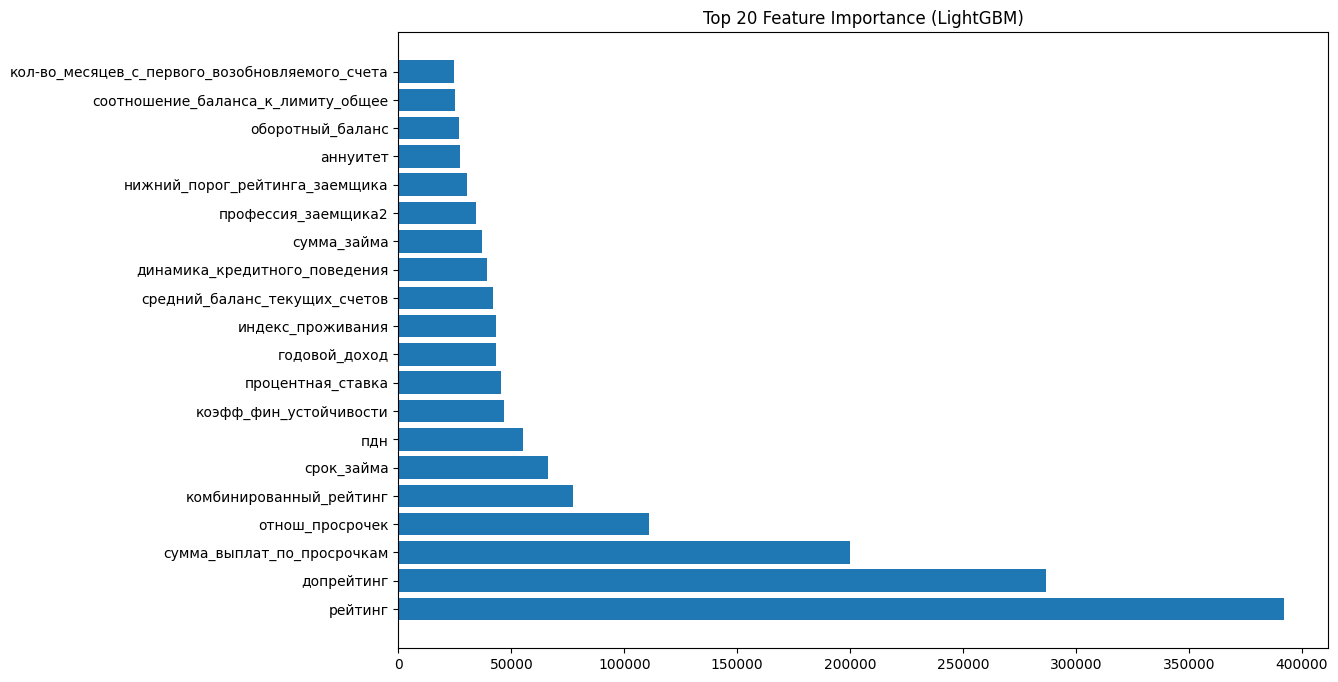

In [ ]:
# Параметры для перебора
param_grid = {
    'num_leaves': [50, 63, 80],  # Аналог max_depth в XGBoost
    'learning_rate': [0.08, 0.1, 0.09],
    'reg_lambda': [1, 3, 5],  # L2 регуляризация
    'min_child_samples': [5, 10, 20],  # Аналог min_child_weight
    'feature_fraction': [0.8, 0.9],  # Аналог colsample_bytree
    'min_split_gain': [0, 0.1, 0.15]  # Аналог gamma
}

# Базовые параметры
base_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 300,
    'random_state': 42,
    'early_stopping_rounds': 30,
    'verbose': -1,
    'scale_pos_weight': 4,  # Учет дисбаланса 1:4
    'bagging_freq': 1,
    'bagging_fraction': 0.8
}

def grid_search_lightgbm(X_train, y_train, X_val, y_val, param_grid, base_params, n_combinations=30):
    best_model = None
    best_params = {}
    best_val_auc = 0
    best_train_auc = 0
    results = []

    # Генерируем случайные комбинации параметров
    keys, values = zip(*param_grid.items())
    random_combinations = [dict(zip(keys, v)) for v in product(*values)]
    np.random.shuffle(random_combinations)
    combinations_to_try = random_combinations[:min(n_combinations, len(random_combinations))]

    print(f"Будет проверено {len(combinations_to_try)} комбинаций параметров...")

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    for i, params in enumerate(combinations_to_try, 1):
        current_params = {**base_params, **params}

        print(f"\n=== Итерация {i}/{len(combinations_to_try)} ===")
        print("Текущие параметры:")
        for param, value in params.items():
            print(f"- {param}: {value}")
        print("="*30)

        model = lgb.train(
            current_params,
            train_data,
            valid_sets=[val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30),
                lgb.log_evaluation(0)
            ]
        )

        train_proba = model.predict(X_train)
        val_proba = model.predict(X_val)

        train_auc = roc_auc_score(y_train, train_proba)
        val_auc = roc_auc_score(y_val, val_proba)

        results.append({
            'params': current_params,
            'train_auc': train_auc,
            'val_auc': val_auc,
            'model': model
        })

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_train_auc = train_auc
            best_params = current_params
            best_model = model

        print(f"Результат | Val AUC: {val_auc:.4f} | Best AUC: {best_val_auc:.4f}")
        print("-"*50)

    # Сортируем все результаты по val_auc
    sorted_results = sorted(results, key=lambda x: x['val_auc'], reverse=True)

    return best_model, best_params, best_train_auc, best_val_auc, sorted_results

# Запуск поиска
best_model, best_params, best_train_auc, best_val_auc, all_results = grid_search_lightgbm(
    X_train, y_train, X_val, y_val, param_grid, base_params, n_combinations=30
)

# Вывод результатов
print("\n=== Лучшая модель ===")
print(f"Лучшие параметры: {best_params}")
print(f"ROC AUC на обучении: {best_train_auc:.4f}")
print(f"ROC AUC на валидации: {best_val_auc:.4f}")

# Дополнительная информация о лучшей модели
print("\n=== Детали лучшей модели ===")
feature_importance = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': best_model.feature_importance(importance_type='gain')
}).sort_values('Важность', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

print("\nОтчет классификации:")
print(classification_report(y_val, np.round(best_model.predict(X_val))))

# Вывод топ-5 комбинаций параметров
print("\n=== Топ-5 комбинаций параметров ===")
for i, res in enumerate(all_results[:5], 1):
    print(f"\n#{i} | Val AUC: {res['val_auc']:.4f}")
    print(f"Параметры: {res['params']}")

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Признак'].head(20), feature_importance['Важность'].head(20))
plt.title('Top 20 Feature Importance (LightGBM)')
plt.show()

# Сохранение модели
# best_model.save_model('best_lgb_model.txt')

## StackingClassifier

In [ ]:
#1. Инициализация моделей
# Для XGBoost
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.09,
    'max_depth': 7,
    'min_child_weight': 10,
    'reg_lambda': 3,
    'grow_policy': 'depthwise',
    'subsample': 0.8,
    'colsample_bytree': 1.0,
    'gamma': 0.0,
    'scale_pos_weight': scale_pos_weight,
    'n_estimators': 300,
    'random_state': 42,
    'n_jobs': -1
}

# Для CatBoost
model_params = {
    'iterations': 300,
    'learning_rate': 0.1,
    'depth': 8,
    'l2_leaf_reg': 3,
    'min_data_in_leaf': 5,
    'grow_policy': 'Depthwise',
    'border_count': 128,
    'random_seed': 42,
    'eval_metric': 'AUC',
    'verbose': 100,
    'auto_class_weights': 'Balanced',
    'task_type': 'CPU'
}


# Инициализация моделей
cat_model = CatBoostClassifier(**model_params)
xgb_model = XGBClassifier(**params)

estimators = [
    ('cat', cat_model),
    ('xgb', xgb_model)
]

# 2. Финальный эстиматор с учетом дисбаланса
final_estimator = LogisticRegression(
    class_weight='balanced',
    penalty='l2',
    C=0.1,
    solver='liblinear',
    random_state=42,
    max_iter=1000
)
# 3. Создание StackingClassifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False,
    verbose=1
)

stacking_model.fit(X_train, y_train)

# 5. Оценка
y_pred_proba = stacking_model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, y_pred_proba)

print(f"ROC-AUC на валидации: {val_auc:.4f}")
print(classification_report(y_val, stacking_model.predict(X_val)))

ROC-AUC: 0.7559
              precision    recall  f1-score   support

           0       0.90      0.68      0.77     96909
           1       0.35      0.70      0.47     24169

    accuracy                           0.68    121078
   macro avg       0.63      0.69      0.62    121078
weighted avg       0.79      0.68      0.71    121078



## Bagging

In [ ]:
# 1. Создаем обертку для LightGBM, совместимую с scikit-learn
class LGBMClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, **params):
        self.params = params
        self.model = None
        self.classes_ = np.array([0, 1])  # Добавляем атрибут classes_

    def get_params(self, deep=True):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        return self

    def fit(self, X, y, eval_set=None):
        train_data = lgb.Dataset(X, label=y)
        if eval_set:
            X_val, y_val = eval_set
            val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
            self.model = lgb.train(
                self.params,
                train_data,
                valid_sets=[val_data],
                callbacks=[
                    lgb.early_stopping(stopping_rounds=30),
                    lgb.log_evaluation(20)
                ]
            )
        else:
            self.model = lgb.train(self.params, train_data)
        return self

    def predict_proba(self, X):
        proba_pos = self.model.predict(X)  # Вероятность класса 1
        return np.vstack([1 - proba_pos, proba_pos]).T  # Формат (n_samples, 2)

    def predict(self, X):
        return (self.model.predict(X) > 0.5).astype(int)

In [ ]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 400,  # Увеличиваем количество деревьев
    'learning_rate': 0.05,  # Уменьшаем learning rate для большей стабильности
    'num_leaves': 63,  # Оптимальное значение ≈ 2^max_depth - 1
    'max_depth': 6,  # Ограничиваем глубину для уменьшения переобучения
    'min_child_samples': 20,  # Более консервативное значение
    'reg_lambda': 5,  # Увеличиваем L2 регуляризацию
    'feature_fraction': 0.8,  # Оптимальный баланс между разнообразием и качеством
    'bagging_fraction': 0.9,  # Увеличиваем долю данных для каждой итерации
    'bagging_freq': 1,
    'min_split_gain': 0.01,  # Более мягкий порог для разделения
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': 1,  # Используем все ядра
    'verbose': 1
}

# 3. Создаем базовую модель LightGBM
base_model = LGBMClassifierWrapper(**params)

bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=15,  # Увеличиваем количество моделей в ансамбле
    max_samples=0.7,  # Уменьшаем размер выборки для большего разнообразия
    max_features=0.7,  # Аналогично для признаков
    bootstrap=False,  # Отключаем бутстрап для более стабильных результатов
    bootstrap_features=False,
    random_state=42,
    n_jobs=1,  # Используем все ядра
    verbose=1
)

# 5. Обучение с ранней остановкой (через eval_set в fit)
print("Обучение Bagging-LightGBM модели...")
bagging_model.fit(X_train.values, y_train.values)

# 6. Оценка модели
def evaluate_model(model, X, y, name):
    if hasattr(model, 'predict_proba'):
        y_pred = model.predict_proba(X)[:, 1]
    else:
        y_pred = model.predict(X)
    auc = roc_auc_score(y, y_pred)
    print(f"ROC-AUC ({name}): {auc:.4f}")
    return auc

print("\nОценка производительности:")
train_auc = evaluate_model(bagging_model, X_train.values, y_train.values, "обучение")
val_auc = evaluate_model(bagging_model, X_val.values, y_val.values, "валидация")

# Сравнение с оригинальной моделью
print("\nСравнение с оригинальной LightGBM моделью:")
print(f"Оригинальная модель - ROC-AUC (валидация): 0.7620")
print(f"Bagging модель - ROC-AUC (валидация): {val_auc:.4f}")

Обучение Bagging-LightGBM модели...
[LightGBM] [Info] Number of positive: 152547, number of negative: 610243
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.379816 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9416
[LightGBM] [Info] Number of data points in the train set: 762790, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199986 -> initscore=-1.386384
[LightGBM] [Info] Start training from score -1.386384
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 30.2min finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  7.6min finished


ROC-AUC (обучение): 0.7755
ROC-AUC (валидация): 0.7623

Сравнение с оригинальной LightGBM моделью:
Оригинальная модель - ROC-AUC (валидация): 0.7620
Bagging модель - ROC-AUC (валидация): 0.7623


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   51.3s finished


In [ ]:
print("\nСравнение с оригинальной LightGBM моделью:")
print(f"Оригинальная модель - ROC-AUC (валидация): 0.7620")
print(f"Bagging модель - ROC-AUC (валидация): {val_auc:.4f}")


Сравнение с оригинальной LightGBM моделью:
Оригинальная модель - ROC-AUC (валидация): 0.7620
Bagging модель - ROC-AUC (валидация): 0.7623
